In [4]:
from final.part_3__Pong_v5_modules.compute_returns import calculate_returns
from final.part_3__Pong_v5_modules.worker import worker_loop
from final.part_3__Pong_v5_modules.ActorCritic import A2CActorCritic
import torch.nn.functional as F
import ale_py



In [8]:
reward_history_env1  = []    
entropy_history_env1 = []     
step_index_env1      = []  

reward_history_env2  = []    
entropy_history_env2 = []     
step_index_env2      = []  

def plot_reward_entropy(rewards, entropies, steps, title="Return vs Entropy"):
    import matplotlib.pyplot as plt
    import numpy as np

    steps = np.asarray(steps)
    fig, ax1 = plt.subplots()

    ax1.set_xlabel("Update")
    ax1.set_ylabel("Average return", color="tab:blue")
    ax1.plot(steps, rewards, color="tab:blue", label="Average return")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Entropy", color="tab:red")
    ax2.plot(steps, entropies, color="tab:red", label="Entropy")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()


In [9]:
import logging,csv,os
logging.basicConfig(level=logging.INFO,format='%(asctime)s %(levelname)s %(message)s',datefmt='%H:%M:%S')

In [14]:
import os, logging, time, torch, numpy as np, torch.multiprocessing as mp
from torch import optim

lr_actor=1e-4
lr_critic=1e-4
gamma=0.99
rollout_steps=6
num_workers=6
max_updates=3000000
initial_ent_coef=0.01
final_ent_coef=0.005
initial_temp=1.5
final_temp=1.0
value_loss_coef=0.5
freeze_critic_iters=0
max_grad_norm=5
save_interval=1000
log_interval=1000
seed=1

device=torch.device('cpu')

def make_optimizers(model):
    pol,cri=[],[]
    for n,p in model.named_parameters():
        if 'value_head' in n:cri.append(p)
        else:
            pol.append(p)
            if 'policy_head' not in n:cri.append(p)
    return optim.Adam(pol,lr=lr_actor,eps=1e-5),optim.Adam(cri,lr=lr_critic,eps=1e-5)

checkpoint_path = 'a3_part_3_a2c_ENV1_ssaurav_asinha25.pth' 

if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)
    torch.manual_seed(seed); np.random.seed(seed)

    model = A2CActorCritic(input_channels=4).to(device)
    torch.nn.init.zeros_(model.policy_head.bias)
    model.share_memory()

    actor_opt, critic_opt = make_optimizers(model)

    start_update = 1
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        if isinstance(ckpt, dict) and 'model' in ckpt:
            model.load_state_dict(ckpt['model'])
            actor_opt.load_state_dict(ckpt['actor_opt'])
            critic_opt.load_state_dict(ckpt['critic_opt'])
            start_update = ckpt.get('update', 1) + 1
            logging.info(f'Resuming from update {start_update-1}')
        else:                              
            model.load_state_dict(ckpt)
            logging.info('Loaded existing weights – optimizers re-initialized')


    exp_q = mp.Queue(maxsize=num_workers * 2)
    for pid in range(num_workers):
        mp.Process(target=worker_loop,
                   args=(pid, exp_q, model, rollout_steps, device),
                   daemon=True).start()

    t0 = time.time()
    for update in range(start_update, max_updates + 1): 
        S, A, R = [], [], []
        for _ in range(num_workers):
            s, a, r, d, lv = exp_q.get()
            G = calculate_returns(r, d, lv, gamma)
            S.extend(s); A.extend(a); R.extend(G)
        states = np.stack(S).astype(np.float32) / 255.0
        s_batch = torch.from_numpy(states).to(device)
        a_batch = torch.tensor(A, device=device)
        r_batch = torch.tensor(R, device=device)

        ratio = update / max_updates
        temp = initial_temp - (initial_temp - final_temp) * ratio
        ent_coef = initial_ent_coef - (initial_ent_coef - final_ent_coef) * ratio
        ent_coef  = max(ent_coef *.1, 0.001)  

        dist, values = model(s_batch, temp)
        logp = dist.log_prob(a_batch)
        ent = dist.entropy().mean()
        adv = r_batch - values.detach()
        adv = (adv - adv.mean()) / (adv.std(unbiased=False) + 1e-8)

        actor_loss = -(logp * adv).mean()
        critic_loss = value_loss_coef * F.smooth_l1_loss(values, r_batch)
        entropy_pen = -ent_coef * ent
        total_loss = actor_loss + critic_loss + entropy_pen

        lr_now = lr_actor * (1 - ratio)
        for g in actor_opt.param_groups: g['lr'] = lr_now
        for g in critic_opt.param_groups: g['lr'] = lr_now

        actor_opt.zero_grad(set_to_none=True)
        critic_opt.zero_grad(set_to_none=True)

        if update <= freeze_critic_iters:
            (actor_loss + entropy_pen).backward()
            torch.nn.utils.clip_grad_norm_(actor_opt.param_groups[0]['params'], max_grad_norm)
            actor_opt.step()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor_opt.param_groups[0]['params'], max_grad_norm)
            torch.nn.utils.clip_grad_norm_(critic_opt.param_groups[0]['params'], max_grad_norm)
            actor_opt.step(); critic_opt.step()

        if update % log_interval == 0:
            fps = (update * num_workers * rollout_steps) / (time.time() - t0)
            avg_return = float(r_batch.mean())
            reward_history_env1.append(avg_return)
            entropy_history_env1.append(ent.item())
            step_index_env1.append(update)
            logging.info(
                f"Update {update:>7}/{max_updates:<7} | "
                f"Avg Return {avg_return:8.1f} | "
                f"Actor Loss {actor_loss.item():8.4f} | "
                f"Critic Loss {critic_loss.item():8.4f} | "
                f"Entropy {ent.item():7.3f} | "
                f"LR {lr_now:.2e} | "
                f"FPS {fps:6.1f} | "
                f"ent_coef {ent_coef:8.4f} | "
            )

        if update % save_interval == 0:
            torch.save(
                {
                    'model': model.state_dict(),
                    'actor_opt': actor_opt.state_dict(),
                    'critic_opt': critic_opt.state_dict(),
                    'update': update
                },
                checkpoint_path
            )

02:27:23 INFO Resuming from update 2000000
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
02:28:23 INFO Update 2001000/3000000 | Avg Return      0.0 | Actor Loss   0.0078 | Critic Loss   0.0000 | Entropy   1.791 | LR 3.33e-05 | FPS 1197165.8 | ent_coef   0.0010 | 
02:29:21 INFO Update 2002000/3000000 | Avg Return      0.0 | Actor Loss   0.0089 | Critic Loss   0.0000 | Entropy   1.791 | LR 3.33e-05 | FPS 608694.2 | ent_coef   0.0010 | 
02:30:20 INFO Update 2003000/3000000 | Avg Return     -0.0 | Actor Loss  -0.0054 | Critic Loss   0.0000 | Entropy   1.791 | LR 3

KeyboardInterrupt: 

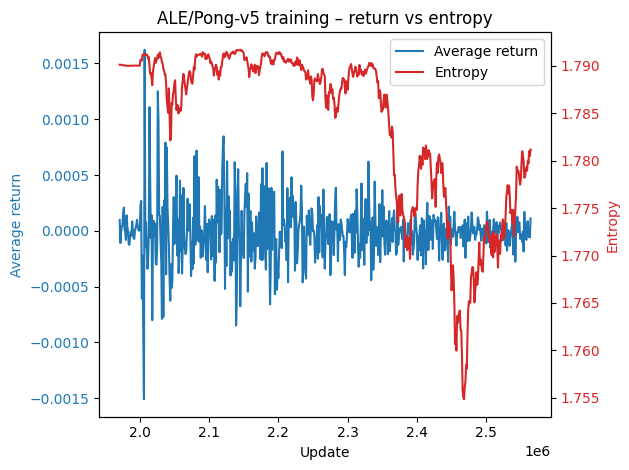

In [15]:
plot_reward_entropy(reward_history_env1,
                    entropy_history_env1,
                    step_index_env1,
                    title="ALE/Pong-v5 training – return vs entropy")

In [2]:
import os, glob, logging
import numpy as np
import torch
import gymnasium as gym
from final.part_3__Pong_v5_modules.ActorCritic import A2CActorCritic
from final.part_3__Pong_v5_modules.FrameStack import FrameStack
from gymnasium.wrappers import AtariPreprocessing
from matplotlib import pyplot as plt
import ale_py

device = torch.device("cpu")

def _latest_checkpoint(pattern='a3_part_3_a2c_ENV1_ssaurav_asinha25*.pth'):
    paths = glob.glob(pattern)
    if not paths:
        return None
    paths.sort(key=lambda p: int(''.join(filter(str.isdigit, os.path.basename(p))) or 0))
    return paths[-1]

def evaluate_policy(
    checkpoint_path: str = None,
    eval_episodes: int = 10,
    human_mode: bool = True,
        show_plot     = True,
):
    path = checkpoint_path or _latest_checkpoint()
    model = A2CActorCritic(input_channels=4).to(device)

    if path and os.path.isfile(path):
        state_dict = torch.load(path, map_location=device)
        if isinstance(state_dict, dict) and "model" in state_dict:
            model.load_state_dict(state_dict["model"])
        else:
            model.load_state_dict(state_dict)
        logging.info(f"Loaded checkpoint: {path}")
    else:
        logging.warning("No checkpoint found, running untrained model.")

    model.eval()
    render_mode = "human" if human_mode else "rgb_array"
    env = gym.make("ALE/Pong-v5", render_mode=render_mode)
    env = AtariPreprocessing(env, screen_size=84, grayscale_obs=True, frame_skip=1)
    env = FrameStack(env, 4)

    returns = []
    with torch.no_grad():
        for ep in range(eval_episodes):
            obs, _ = env.reset()
            done = False
            ep_ret = 0.0
            while not done:
                obs_tensor = (
                    torch.from_numpy(obs.astype(np.float32) / 255.0)
                    .unsqueeze(0)
                    .to(device)
                )
                dist, _ = model(obs_tensor)
                action = dist.sample().item()
                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                ep_ret += reward
            returns.append(ep_ret)
            logging.info(f"Episode {ep+1}/{eval_episodes}: Return {ep_ret:.2f}")

    avg = float(np.mean(returns))
    std = float(np.std(returns))
    logging.info(f"Eval Result → Avg: {avg:.2f} | Std: {std:.2f}")
    
    if show_plot:
        plt.figure(figsize=(6,3))
        plt.plot(returns, marker='o')
        plt.axhline(avg, ls='--')
        plt.title(f"Evaluation at update {2500000}\nμ={avg:.1f}  σ={std:.1f}")
        plt.xlabel("Episode")
        plt.ylabel("Return")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    return avg, std

    

A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]


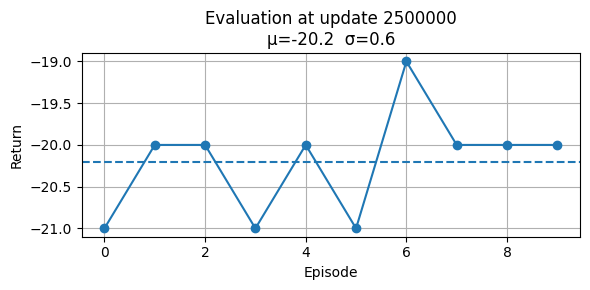

(-20.2, 0.6)

In [3]:
evaluate_policy()